# 01 Online Retail Data Preparation

## Scope

Prepare the Online Retail transaction layer for the ReturnShield pipeline.

Pipeline data outputs:

```text
data/processed/online_retail_eda_features.csv
data/processed/online_retail_model_base.csv
```

Notebook-specific reports and plots:

```text
outputs/01_online_retail_data_preparation/
```


## Dataset Scope

Online Retail contains invoice-level retail transaction records.

In ReturnShield, this dataset represents the historical transaction layer. Fashion-specific signals are handled as separate project layers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

CURRENT_DIR = Path.cwd().resolve()
BASE_DIR = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

RAW_DATA_CANDIDATES = [
    BASE_DIR / "data" / "raw" / "online_retail" / "data.csv",
    BASE_DIR / "data" / "raw" / "online_retail.csv",
    BASE_DIR / "data" / "raw" / "data.csv",
    BASE_DIR / "data" / "data.csv",
    CURRENT_DIR / "data.csv",
]

RAW_DATA_PATH = next((path for path in RAW_DATA_CANDIDATES if path.exists()), None)
if RAW_DATA_PATH is None:
    searched_paths = "\n".join(str(path) for path in RAW_DATA_CANDIDATES)
    raise FileNotFoundError(f"Raw Online Retail CSV file was not found. Searched paths:\n{searched_paths}")

DATA_PROCESSED = BASE_DIR / "data" / "processed"
OUTPUTS_DIR = BASE_DIR / "outputs"
NOTEBOOK_OUTPUT_DIR = OUTPUTS_DIR / "01_online_retail_data_preparation"
PLOTS_DIR = NOTEBOOK_OUTPUT_DIR / "plots"

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
NOTEBOOK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

EDA_OUTPUT_PATH = DATA_PROCESSED / "online_retail_eda_features.csv"
MODEL_BASE_OUTPUT_PATH = DATA_PROCESSED / "online_retail_model_base.csv"

RAW_OVERVIEW_OUTPUT_PATH = NOTEBOOK_OUTPUT_DIR / "raw_overview.csv"
NON_PRODUCT_SUMMARY_OUTPUT_PATH = NOTEBOOK_OUTPUT_DIR / "non_product_summary.csv"
CLEANING_SUMMARY_OUTPUT_PATH = NOTEBOOK_OUTPUT_DIR / "cleaning_summary.csv"
LABEL_SUMMARY_OUTPUT_PATH = NOTEBOOK_OUTPUT_DIR / "label_summary.csv"
HOURLY_STATS_OUTPUT_PATH = NOTEBOOK_OUTPUT_DIR / "hourly_return_cancel_stats.csv"
HISTORY_COVERAGE_OUTPUT_PATH = NOTEBOOK_OUTPUT_DIR / "history_coverage.csv"
OUTPUT_TABLE_SUMMARY_PATH = NOTEBOOK_OUTPUT_DIR / "output_table_summary.csv"
MISSING_SUMMARY_OUTPUT_PATH = NOTEBOOK_OUTPUT_DIR / "model_base_missing_summary.csv"

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.6f}".format)

print("Processed data dir:", DATA_PROCESSED)
print("Notebook output dir:", NOTEBOOK_OUTPUT_DIR)
print("Plots dir:", PLOTS_DIR)


Processed data dir: C:\Users\monster\Desktop\returnshield-ai\data\processed
Notebook output dir: C:\Users\monster\Desktop\returnshield-ai\outputs\01_online_retail_data_preparation
Plots dir: C:\Users\monster\Desktop\returnshield-ai\outputs\01_online_retail_data_preparation\plots


In [2]:
df = pd.read_csv(RAW_DATA_PATH, encoding='ISO-8859-1')

print('Source file:', RAW_DATA_PATH)
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])

df.head()

Source file: C:\Users\monster\Desktop\returnshield-ai\data\raw\online_retail\data.csv
Rows: 541909
Columns: 8


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.550000,17850.000000,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.390000,17850.000000,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.750000,17850.000000,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.390000,17850.000000,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.390000,17850.000000,United Kingdom


## Raw Data Overview

The raw table contains invoice, product, quantity, timestamp, price, customer, and country fields.

In [3]:
raw_overview = pd.DataFrame({
    'column': df.columns,
    'dtype': df.dtypes.astype(str).values,
    'missing_count': df.isna().sum().values,
    'missing_rate': df.isna().mean().values,
    'unique_count': df.nunique(dropna=True).values,
})

raw_overview

,column,dtype,missing_count,missing_rate,unique_count
0,InvoiceNo,object,0,0.000000,25900
1,StockCode,object,0,0.000000,4070
2,Description,object,1454,0.002683,4223
3,Quantity,int64,0,0.000000,722
4,InvoiceDate,object,0,0.000000,23260
5,UnitPrice,float64,0,0.000000,1630
6,CustomerID,float64,135080,0.249267,4372
7,Country,object,0,0.000000,38


## Return/Cancel Proxy Label

The dataset contains cancelled invoices and negative quantity rows.

This notebook defines `is_return` as a line-item return/cancel proxy using two rules:

- invoices starting with `C`
- rows with negative `Quantity`

The proxy does not link a later return row back to the original purchase row. It gives a Sprint 1 transaction-level target for baseline modeling.

In [4]:
work_df = df.copy()

work_df['InvoiceNo'] = work_df['InvoiceNo'].astype(str)
work_df['InvoiceDate'] = pd.to_datetime(work_df['InvoiceDate'], errors='coerce')

work_df['is_return'] = (
    work_df['InvoiceNo'].str.startswith('C') | (work_df['Quantity'] < 0)
).astype(int)

label_summary = (
    work_df['is_return']
    .value_counts()
    .rename(index={0: 'not_return', 1: 'return_cancel'})
    .to_frame('row_count')
)
label_summary['rate'] = label_summary['row_count'] / label_summary['row_count'].sum()

label_rule_check = pd.DataFrame({
    'metric': [
        'cancelled_invoice_rows',
        'negative_quantity_rows',
        'return_cancel_proxy_rows',
    ],
    'row_count': [
        work_df['InvoiceNo'].str.startswith('C').sum(),
        (work_df['Quantity'] < 0).sum(),
        work_df['is_return'].sum(),
    ],
})

display(label_summary)
display(label_rule_check)

,row_count,rate
is_return,,
not_return,531285,0.980395
return_cancel,10624,0.019605


,metric,row_count
0,cancelled_invoice_rows,9288
1,negative_quantity_rows,10624
2,return_cancel_proxy_rows,10624


## Cleaning Criteria

The cleaned table excludes non-product stock codes and rows with non-positive unit prices.

The removed stock codes represent postage, discounts, manual adjustments, bank charges, marketplace fees, or other non-product transactions.

In [5]:
non_product_codes = [
    'POST', 'DOT', 'M', 'BANK CHARGES', 'AMAZONFEE', 'D', 'CRUK'
]

non_product_summary = (
    work_df[work_df['StockCode'].isin(non_product_codes)]
    .groupby('StockCode')
    .agg(
        row_count=('StockCode', 'count'),
        return_cancel_rate=('is_return', 'mean'),
        average_unit_price=('UnitPrice', 'mean'),
    )
    .reset_index()
    .sort_values('row_count', ascending=False)
)

clean_df = work_df[
    (~work_df['StockCode'].isin(non_product_codes)) &
    (work_df['UnitPrice'] > 0)
].copy()

cleaned_summary = pd.DataFrame({
    'metric': ['raw_rows', 'clean_rows', 'removed_rows', 'removed_rate'],
    'value': [
        work_df.shape[0],
        clean_df.shape[0],
        work_df.shape[0] - clean_df.shape[0],
        (work_df.shape[0] - clean_df.shape[0]) / work_df.shape[0],
    ],
})

clean_label_summary = (
    clean_df['is_return']
    .value_counts()
    .rename(index={0: 'not_return', 1: 'return_cancel'})
    .to_frame('row_count')
)
clean_label_summary['rate'] = clean_label_summary['row_count'] / clean_label_summary['row_count'].sum()

display(non_product_summary)
display(cleaned_summary)
display(clean_label_summary)

,StockCode,row_count,return_cancel_rate,average_unit_price
6,POST,1256,0.100318,36.933495
4,DOT,710,0.001408,290.495859
5,M,571,0.427320,375.566392
3,D,77,1.000000,72.484545
1,BANK CHARGES,37,0.675676,202.855162
0,AMAZONFEE,34,0.941176,7324.784706
2,CRUK,16,1.000000,495.839375


,metric,value
0,raw_rows,541909.000000
1,clean_rows,536704.000000
2,removed_rows,5205.000000
3,removed_rate,0.009605


,row_count,rate
is_return,,
not_return,527937,0.983665
return_cancel,8767,0.016335


## Price and Time Signals

`UnitPrice` is right-skewed. `InvoiceDate` provides hour, weekday, and month signals for the transaction layer.

In [6]:
price_summary = clean_df['UnitPrice'].describe(
    percentiles=[0.01, 0.25, 0.50, 0.75, 0.95, 0.99]
)

clean_df['invoice_hour'] = clean_df['InvoiceDate'].dt.hour
clean_df['invoice_dayofweek'] = clean_df['InvoiceDate'].dt.dayofweek
clean_df['invoice_month'] = clean_df['InvoiceDate'].dt.month
clean_df['evening_purchase'] = clean_df['invoice_hour'].isin([17, 18, 19, 20]).astype(int)

hourly_stats = (
    clean_df.groupby('invoice_hour')
    .agg(
        row_count=('InvoiceNo', 'count'),
        return_cancel_count=('is_return', 'sum'),
        return_cancel_rate=('is_return', 'mean'),
    )
    .reset_index()
)

evening_stats = (
    clean_df.groupby('evening_purchase')
    .agg(
        row_count=('InvoiceNo', 'count'),
        return_cancel_count=('is_return', 'sum'),
        return_cancel_rate=('is_return', 'mean'),
    )
    .rename(index={0: 'not_evening', 1: 'evening'})
)

display(price_summary)
display(hourly_stats)
display(evening_stats)

count   536704.000000
mean         3.323575
std         15.805510
min          0.001000
1%           0.290000
25%          1.250000
50%          2.080000
75%          4.130000
95%          9.950000
99%         16.630000
max      11062.060000
Name: UnitPrice, dtype: float64

,invoice_hour,row_count,return_cancel_count,return_cancel_rate
0,6,39,38,0.974359
1,7,380,4,0.010526
2,8,8845,99,0.011193
3,9,34017,502,0.014757
4,10,48507,964,0.019873
5,11,57052,1113,0.019509
6,12,78102,1218,0.015595
7,13,71756,1009,0.014062
8,14,66647,958,0.014374
9,15,76722,836,0.010896


,row_count,return_cancel_count,return_cancel_rate
evening_purchase,,,
not_evening,496103,7629,0.015378
evening,40601,1138,0.028029


## Customer and Product History Signals

Customer and product history fields are created for EDA inspection with leave-one-out logic.

The modeling base output keeps source fields and excludes full-dataset aggregate return rates. The modeling notebook recreates aggregate history after the temporal split using training data only.

In [7]:
customer_group = clean_df.groupby('CustomerID')['is_return']
customer_return_sum = customer_group.transform('sum')
customer_row_count = customer_group.transform('count')

clean_df['customer_history_available'] = clean_df['CustomerID'].notna().astype(int)
clean_df['customer_history_count'] = customer_row_count.fillna(0).astype(int)
clean_df['customer_return_cancel_rate_loo'] = (
    (customer_return_sum - clean_df['is_return']) / (customer_row_count - 1)
)
clean_df['customer_return_cancel_rate_loo'] = (
    clean_df['customer_return_cancel_rate_loo']
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)
clean_df['customer_history_reliable'] = (clean_df['customer_history_count'] >= 10).astype(int)

product_group = clean_df.groupby('StockCode')['is_return']
product_return_sum = product_group.transform('sum')
product_row_count = product_group.transform('count')

clean_df['product_history_count'] = product_row_count.fillna(0).astype(int)
clean_df['product_return_cancel_rate_loo'] = (
    (product_return_sum - clean_df['is_return']) / (product_row_count - 1)
)
clean_df['product_return_cancel_rate_loo'] = (
    clean_df['product_return_cancel_rate_loo']
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)
clean_df['product_history_reliable'] = (clean_df['product_history_count'] >= 20).astype(int)

history_coverage = pd.DataFrame({
    'feature': [
        'customer_history_available',
        'customer_history_reliable',
        'product_history_reliable',
    ],
    'rate': [
        clean_df['customer_history_available'].mean(),
        clean_df['customer_history_reliable'].mean(),
        clean_df['product_history_reliable'].mean(),
    ],
})

history_coverage

,feature,rate
0,customer_history_available,0.754630
1,customer_history_reliable,0.749085
2,product_history_reliable,0.985577


## Output Tables

Two output tables are exported.

`online_retail_eda_features.csv` contains extended inspection fields.

`online_retail_model_base.csv` contains the modeling base table with `InvoiceDate` preserved for temporal evaluation.

In [8]:
clean_df['log_unit_price'] = np.log1p(clean_df['UnitPrice'])

eda_feature_columns = [
    'InvoiceDate',
    'StockCode',
    'Description',
    'CustomerID',
    'Country',
    'UnitPrice',
    'log_unit_price',
    'invoice_hour',
    'invoice_dayofweek',
    'invoice_month',
    'evening_purchase',
    'customer_history_available',
    'customer_history_count',
    'customer_history_reliable',
    'customer_return_cancel_rate_loo',
    'product_history_count',
    'product_history_reliable',
    'product_return_cancel_rate_loo',
    'is_return',
]

model_base_columns = [
    'InvoiceDate',
    'StockCode',
    'Description',
    'CustomerID',
    'Country',
    'log_unit_price',
    'invoice_hour',
    'invoice_dayofweek',
    'invoice_month',
    'evening_purchase',
    'customer_history_available',
    'is_return',
]

eda_feature_df = clean_df[eda_feature_columns].copy()
model_base_df = clean_df[model_base_columns].copy()

output_summary = pd.DataFrame({
    'table': ['eda_feature_df', 'model_base_df'],
    'rows': [eda_feature_df.shape[0], model_base_df.shape[0]],
    'columns': [eda_feature_df.shape[1], model_base_df.shape[1]],
})

missing_summary = (
    model_base_df.isna().sum().sort_values(ascending=False).reset_index()
)
missing_summary.columns = ['column', 'missing_count']
missing_summary['missing_rate'] = missing_summary['missing_count'] / len(model_base_df)

display(output_summary)
display(missing_summary)

,table,rows,columns
0,eda_feature_df,536704,19
1,model_base_df,536704,12


,column,missing_count,missing_rate
0,CustomerID,131691,0.245370
1,InvoiceDate,0,0.000000
2,StockCode,0,0.000000
3,Description,0,0.000000
4,Country,0,0.000000
5,log_unit_price,0,0.000000
6,invoice_hour,0,0.000000
7,invoice_dayofweek,0,0.000000
8,invoice_month,0,0.000000
9,evening_purchase,0,0.000000


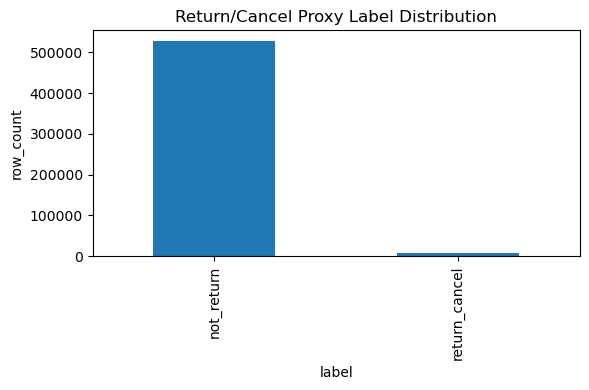

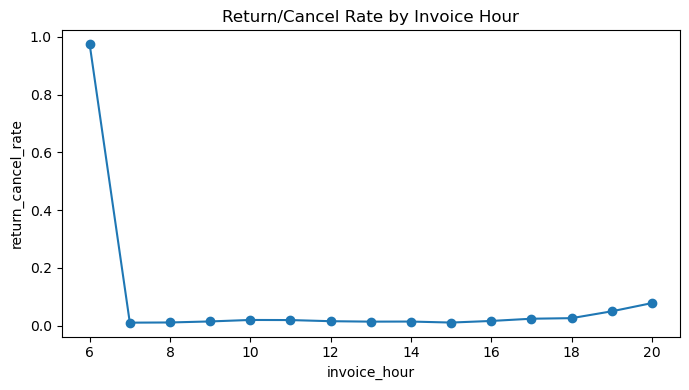

Saved pipeline data: C:\Users\monster\Desktop\returnshield-ai\data\processed\online_retail_eda_features.csv
Saved pipeline data: C:\Users\monster\Desktop\returnshield-ai\data\processed\online_retail_model_base.csv
Saved notebook outputs: C:\Users\monster\Desktop\returnshield-ai\outputs\01_online_retail_data_preparation
Saved plots: C:\Users\monster\Desktop\returnshield-ai\outputs\01_online_retail_data_preparation\plots


In [9]:
eda_feature_df.to_csv(EDA_OUTPUT_PATH, index=False)
model_base_df.to_csv(MODEL_BASE_OUTPUT_PATH, index=False)

raw_overview.to_csv(RAW_OVERVIEW_OUTPUT_PATH, index=False)
non_product_summary.to_csv(NON_PRODUCT_SUMMARY_OUTPUT_PATH, index=False)
cleaned_summary.to_csv(CLEANING_SUMMARY_OUTPUT_PATH, index=False)
clean_label_summary.reset_index().rename(columns={"index": "label"}).to_csv(LABEL_SUMMARY_OUTPUT_PATH, index=False)
hourly_stats.to_csv(HOURLY_STATS_OUTPUT_PATH, index=False)
history_coverage.to_csv(HISTORY_COVERAGE_OUTPUT_PATH, index=False)
output_summary.to_csv(OUTPUT_TABLE_SUMMARY_PATH, index=False)
missing_summary.to_csv(MISSING_SUMMARY_OUTPUT_PATH, index=False)

plt.figure(figsize=(6, 4))
clean_label_summary["row_count"].plot(kind="bar")
plt.title("Return/Cancel Proxy Label Distribution")
plt.xlabel("label")
plt.ylabel("row_count")
plt.tight_layout()
label_plot_path = PLOTS_DIR / "return_cancel_label_distribution.png"
plt.savefig(label_plot_path, dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(hourly_stats["invoice_hour"], hourly_stats["return_cancel_rate"], marker="o")
plt.title("Return/Cancel Rate by Invoice Hour")
plt.xlabel("invoice_hour")
plt.ylabel("return_cancel_rate")
plt.tight_layout()
hourly_plot_path = PLOTS_DIR / "return_cancel_rate_by_hour.png"
plt.savefig(hourly_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved pipeline data:", EDA_OUTPUT_PATH)
print("Saved pipeline data:", MODEL_BASE_OUTPUT_PATH)
print("Saved notebook outputs:", NOTEBOOK_OUTPUT_DIR)
print("Saved plots:", PLOTS_DIR)


## Notebook Summary

The cleaned dataset contains line-item transaction rows with a return/cancel proxy label.

The modeling base table preserves `InvoiceDate` for temporal validation and excludes leakage-prone fields such as `InvoiceNo`, raw `Quantity`, and full-dataset aggregate return rates.

The next notebook builds leakage-controlled baseline models using train-only history features.